# Day 1 — Finalize Experiments
**Paper:** Can Synthetic Data Replace Real Data? (SLTE Framework)

**Tasks:**
1. Data preprocessing + CTGAN synthetic generation
2. Baseline real-data classifier training
3. TSTR protocol across 5 classifiers × 6 mixing ratios
4. Save all raw result logs

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print("--- Checking Local Colab Storage ---")
local_files = os.listdir('.')
for f in ['synthetic_full.csv', 'tstr_results.csv']:
    print(f"Is {f} in local storage?: {f in local_files}")

print("\n--- Checking Google Drive 'Ai' Folder ---")
drive_path = '/content/drive/MyDrive/Ai/'
if os.path.exists(drive_path):
    drive_files = os.listdir(drive_path)
    for f in ['synthetic_full.csv', 'tstr_results.csv']:
        print(f"Is {f} in Google Drive?: {f in drive_files}")
else:
    print("Google Drive 'Ai' folder path not detected. Try running: drive.mount('/content/drive')")

--- Checking Local Colab Storage ---
Is synthetic_full.csv in local storage?: False
Is tstr_results.csv in local storage?: False

--- Checking Google Drive 'Ai' Folder ---
Google Drive 'Ai' folder path not detected. Try running: drive.mount('/content/drive')


In [ ]:
!pip install ctgan -q
!pip install sdmetrics -q
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.8 MB/s eta 0:00:00
✅ Dependencies installed


In [ ]:
import pandas as pd
import numpy as np
import json, os, warnings
from datetime import datetime

from ctgan import CTGAN

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

warnings.filterwarnings('ignore')
np.random.seed(42)
print('✅ Imports done')

✅ Imports done


In [ ]:
df_raw = pd.read_csv('drive/MyDrive/Ai/MedicalAppointment.csv')
print(f'Raw shape: {df_raw.shape}')
print(f'Target distribution:\n{df_raw["No-show"].value_counts()}')

df = df_raw.copy()

# 1. Drop ID columns — not features
df.drop(columns=['PatientId', 'AppointmentID'], inplace=True)

# 2. Fix invalid Age (Age = -1 found in data)
df = df[df['Age'] >= 0].copy()
print(f'After removing Age<0: {df.shape}')

# 3. Feature engineering from dates
df['ScheduledDay']   = pd.to_datetime(df['ScheduledDay'],   utc=True)
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], utc=True)
df['WaitDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df['WaitDays'] = df['WaitDays'].clip(lower=0)  # remove negative wait (same-day edge cases)
df['ScheduledDayOfWeek']    = df['ScheduledDay'].dt.dayofweek
df['AppointmentDayOfWeek']  = df['AppointmentDay'].dt.dayofweek
df['ScheduledMonth']        = df['ScheduledDay'].dt.month
df.drop(columns=['ScheduledDay', 'AppointmentDay'], inplace=True)

# 4. Encode Gender (F=0, M=1)
df['Gender'] = (df['Gender'] == 'M').astype(int)

# 5. Encode Neighbourhood — frequency encoding (better than 81 dummies for CTGAN)
freq_map = df['Neighbourhood'].value_counts(normalize=True).to_dict()
df['Neighbourhood_freq'] = df['Neighbourhood'].map(freq_map)
df.drop(columns=['Neighbourhood'], inplace=True)

# 6. Encode target: No-show Yes=1, No=0
df['No-show'] = (df['No-show'] == 'Yes').astype(int)

print(f'\nFinal processed shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nTarget distribution:')
print(df['No-show'].value_counts())
print(f'Class ratio: {df["No-show"].value_counts()[0] / df["No-show"].value_counts()[1]:.2f}:1')
print('\n✅ Preprocessing complete')

Raw shape: (110527, 14)
Target distribution:
No-show
No     88208
Yes    22319
Name: count, dtype: int64
After removing Age<0: (110526, 12)

Final processed shape: (110526, 14)
Columns: ['Gender', 'Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show', 'WaitDays', 'ScheduledDayOfWeek', 'AppointmentDayOfWeek', 'ScheduledMonth', 'Neighbourhood_freq']

Target distribution:
No-show
0    88207
1    22319
Name: count, dtype: int64
Class ratio: 3.95:1

✅ Preprocessing complete


In [ ]:
# Train/Test split (fixed real test set — never changes)
TARGET = 'No-show'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

# 80% train pool (used for mixing), 20% real test (FIXED — used in all TSTR evaluations)
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train pool size : {X_train_real.shape[0]:,}')
print(f'Test set size   : {X_test_real.shape[0]:,}  ← FIXED, never changes')
print(f'Test class dist : {y_test_real.value_counts().to_dict()}')
print('\n✅ Split complete')

Train pool size : 88,420
Test set size   : 22,106  ← FIXED, never changes
Test class dist : {0: 17642, 1: 4464}

✅ Split complete


In [ ]:
# TASK 1: Train CTGAN & generate synthetic data
# Discrete columns for CTGAN (binary + target)
discrete_cols = ['Gender', 'Scholarship', 'Hipertension', 'Diabetes',
                 'Alcoholism', 'Handcap', 'SMS_received',
                 'ScheduledDayOfWeek', 'AppointmentDayOfWeek',
                 'ScheduledMonth', TARGET]
discrete_cols = [c for c in discrete_cols if c in df.columns]

# Training data for CTGAN = full train pool with target
train_pool_df = pd.concat([X_train_real, y_train_real], axis=1)

print('Training CTGAN... (this takes ~10-15 min on Colab)')
print('Tip: Enable GPU in Colab → Runtime > Change runtime type > GPU')

ctgan = CTGAN(
    epochs=300,
    batch_size=500,
    generator_dim=(256, 256),
    discriminator_dim=(256, 256),
    generator_lr=2e-4,
    discriminator_lr=2e-4,
    discriminator_steps=1,
    pac=10,
    verbose=True
)

ctgan.fit(train_pool_df, discrete_cols)

# Generate synthetic data — same size as training pool
n_synth = len(train_pool_df)
synthetic_df = ctgan.sample(n_synth)

# Post-process synthetic: clip Age, WaitDays, binary columns to valid ranges
synthetic_df['Age']      = synthetic_df['Age'].clip(0, 115).round().astype(int)
synthetic_df['WaitDays'] = synthetic_df['WaitDays'].clip(0).round().astype(int)
for col in ['Gender','Scholarship','Hipertension','Diabetes','Alcoholism','SMS_received',TARGET]:
    if col in synthetic_df.columns:
        synthetic_df[col] = synthetic_df[col].round().clip(0,1).astype(int)
synthetic_df['Handcap'] = synthetic_df['Handcap'].round().clip(0,4).astype(int)

# Save
synthetic_df.to_csv('synthetic_full.csv', index=False)
ctgan.save('ctgan_model.pkl')

print(f'\nSynthetic shape: {synthetic_df.shape}')
print(f'Synthetic target dist:\n{synthetic_df[TARGET].value_counts()}')
print('\n✅ TASK 1 COMPLETE — synthetic_full.csv & ctgan_model.pkl saved')

Training CTGAN... (this takes ~10-15 min on Colab)
Tip: Enable GPU in Colab → Runtime > Change runtime type > GPU


Gen. (-01.13) | Discrim. (-00.12): 100%|██████████| 300/300 [27:49<00:00,  5.57s/it]



Synthetic shape: (88420, 14)
Synthetic target dist:
No-show
0    74122
1    14298
Name: count, dtype: int64

✅ TASK 1 COMPLETE — synthetic_full.csv & ctgan_model.pkl saved


In [ ]:
# TASK 2: Baseline — train on 100% REAL data
CLASSIFIERS = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Naive Bayes'         : GaussianNB(),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1] if hasattr(model, 'predict_proba') else y_pred
    return {
        'accuracy' : round(accuracy_score(y_te, y_pred),    4),
        'f1'       : round(f1_score(y_te, y_pred),          4),
        'precision': round(precision_score(y_te, y_pred),   4),
        'recall'   : round(recall_score(y_te, y_pred),      4),
        'auc_roc'  : round(roc_auc_score(y_te, y_prob),     4),
    }

print('Training baselines on 100% real data...')
baseline_results = {}
for name, clf in CLASSIFIERS.items():
    from sklearn.base import clone
    res = evaluate(clone(clf), X_train_real, y_train_real, X_test_real, y_test_real)
    baseline_results[name] = res
    print(f'  {name:25s} → Acc={res["accuracy"]:.4f}  F1={res["f1"]:.4f}  AUC={res["auc_roc"]:.4f}')

# Save baseline
with open('baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print('\n✅ TASK 2 COMPLETE — baseline_results.json saved')

Training baselines on 100% real data...
  Logistic Regression       → Acc=0.6613  F1=0.4105  AUC=0.6659
  Naive Bayes               → Acc=0.7665  F1=0.2294  AUC=0.6496
  Decision Tree             → Acc=0.6054  F1=0.4379  AUC=0.7154
  Random Forest             → Acc=0.7751  F1=0.2539  AUC=0.7135
  Gradient Boosting         → Acc=0.7980  F1=0.0062  AUC=0.7298

✅ TASK 2 COMPLETE — baseline_results.json saved


In [ ]:
# TASK 3: TSTR protocol — 5 classifiers × 6 mixing ratios

# Mixing ratios = proportion of SYNTHETIC in training data
MIXING_RATIOS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
# 0.0 = 100% real (= baseline), 1.0 = 100% synthetic (pure TSTR)

X_synth = synthetic_df[FEATURES]
y_synth = synthetic_df[TARGET]

all_results = []  # list of dicts → will become results table

n_train = len(X_train_real)  # keep total training size fixed across ratios

print(f'Running TSTR: {len(CLASSIFIERS)} classifiers × {len(MIXING_RATIOS)} ratios = {len(CLASSIFIERS)*len(MIXING_RATIOS)} runs\n')

for ratio in MIXING_RATIOS:
    # Build mixed training set
    n_synth_use = int(n_train * ratio)
    n_real_use  = n_train - n_synth_use

    if n_real_use > 0 and n_synth_use > 0:
        X_real_sample = X_train_real.sample(n=n_real_use, random_state=42)
        y_real_sample = y_train_real.loc[X_real_sample.index]
        X_synth_sample = X_synth.sample(n=n_synth_use, random_state=42)
        y_synth_sample = y_synth.loc[X_synth_sample.index]
        X_mix = pd.concat([X_real_sample, X_synth_sample]).reset_index(drop=True)
        y_mix = pd.concat([y_real_sample, y_synth_sample]).reset_index(drop=True)
    elif n_real_use == 0:
        X_mix = X_synth.sample(n=n_train, random_state=42).reset_index(drop=True)
        y_mix = y_synth.sample(n=n_train, random_state=42).reset_index(drop=True)
    else:
        X_mix = X_train_real.copy().reset_index(drop=True)
        y_mix = y_train_real.copy().reset_index(drop=True)

    print(f'Ratio {ratio:.1f} (synth={n_synth_use:,} / real={n_real_use:,})')

    for name, clf in CLASSIFIERS.items():
        from sklearn.base import clone
        res = evaluate(clone(clf), X_mix, y_mix, X_test_real, y_test_real)
        row = {
            'synthetic_ratio': ratio,
            'n_synthetic'    : n_synth_use,
            'n_real'         : n_real_use,
            'classifier'     : name,
            **res
        }
        all_results.append(row)
        print(f'    {name:25s} → Acc={res["accuracy"]:.4f}  F1={res["f1"]:.4f}  AUC={res["auc_roc"]:.4f}')
    print()

# Save results
results_df = pd.DataFrame(all_results)
results_df.to_csv('tstr_results.csv', index=False)
with open('tstr_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('✅ TASK 3 COMPLETE — tstr_results.csv & tstr_results.json saved')

Running TSTR: 5 classifiers × 6 ratios = 30 runs

Ratio 0.0 (synth=0 / real=88,420)
    Logistic Regression       → Acc=0.6613  F1=0.4105  AUC=0.6659
    Naive Bayes               → Acc=0.7665  F1=0.2294  AUC=0.6496
    Decision Tree             → Acc=0.6054  F1=0.4379  AUC=0.7154
    Random Forest             → Acc=0.7751  F1=0.2539  AUC=0.7135
    Gradient Boosting         → Acc=0.7980  F1=0.0062  AUC=0.7298

Ratio 0.2 (synth=17,684 / real=70,736)
    Logistic Regression       → Acc=0.6594  F1=0.4081  AUC=0.6618
    Naive Bayes               → Acc=0.7711  F1=0.2032  AUC=0.6478
    Decision Tree             → Acc=0.5867  F1=0.4387  AUC=0.7113
    Random Forest             → Acc=0.7782  F1=0.2243  AUC=0.7066
    Gradient Boosting         → Acc=0.7980  F1=0.0004  AUC=0.7256

Ratio 0.4 (synth=35,368 / real=53,052)
    Logistic Regression       → Acc=0.6410  F1=0.3985  AUC=0.6525
    Naive Bayes               → Acc=0.7816  F1=0.1527  AUC=0.6424
    Decision Tree             → Acc=0.5884  

=== ACCURACY — Classifier × Synthetic Ratio ===
classifier       Decision Tree  Gradient Boosting  Logistic Regression  Naive Bayes  Random Forest
synthetic_ratio                                                                                   
0.0                     0.6054             0.7980               0.6613       0.7665         0.7751
0.2                     0.5867             0.7980               0.6594       0.7711         0.7782
0.4                     0.5884             0.7981               0.6410       0.7816         0.7808
0.6                     0.5823             0.7980               0.6149       0.7936         0.7831
0.8                     0.6067             0.7981               0.5918       0.7971         0.7856
1.0                     0.6106             0.7981               0.5722       0.7958         0.7914

=== ACCURACY DEGRADATION (0% → 100% synthetic) ===
     parametric  Logistic Regression      : -13.47%
     parametric  Naive Bayes              : --3.82%
  ⚠️

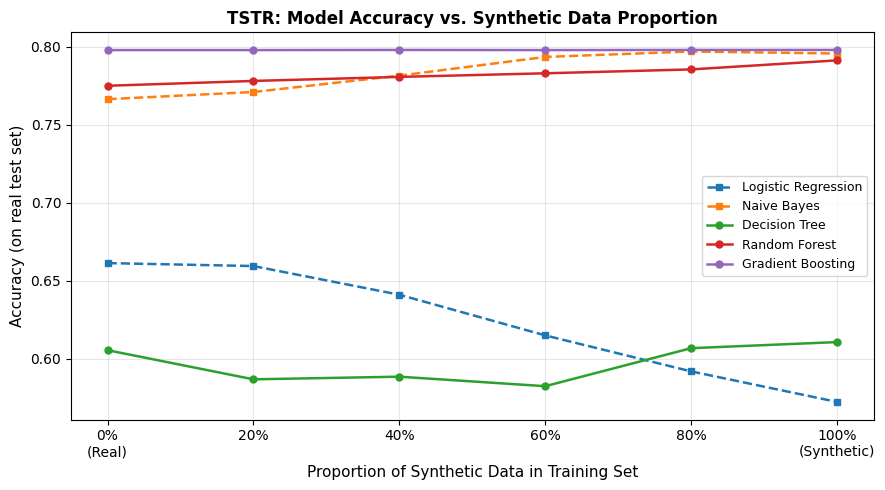


✅ TASK 4 COMPLETE — all logs frozen

Files saved:
  synthetic_full.csv          ← synthetic dataset
  ctgan_model.pkl             ← trained CTGAN model
  baseline_results.json       ← 100% real baselines
  tstr_results.csv/.json      ← all TSTR runs
  results_pivot_accuracy.csv  ← paper Table ready
  fig1_tstr_accuracy_curve.png← paper Figure 1 ready
  day1_summary_log.json       ← complete audit log

🎯 DAY 1 COMPLETE — ALL TASKS DONE


In [ ]:
# TASK 4: Summary table + key numbers for paper

import matplotlib.pyplot as plt

results_df = pd.read_csv('tstr_results.csv')

# ── Pivot table: Accuracy by classifier × ratio ──────────────────────────
pivot = results_df.pivot_table(
    index='synthetic_ratio', columns='classifier', values='accuracy'
).round(4)
print('=== ACCURACY — Classifier × Synthetic Ratio ===')
print(pivot.to_string())
pivot.to_csv('results_pivot_accuracy.csv')

# ── Degradation vs baseline (ratio 0.0) ──────────────────────────────────
baseline_acc = results_df[results_df['synthetic_ratio']==0.0].set_index('classifier')['accuracy']
full_synth_acc = results_df[results_df['synthetic_ratio']==1.0].set_index('classifier')['accuracy']
degradation = ((baseline_acc - full_synth_acc) / baseline_acc * 100).round(2)

print('\n=== ACCURACY DEGRADATION (0% → 100% synthetic) ===')
for clf, deg in degradation.items():
    tag = '⚠️  TREE-BASED' if clf in ['Decision Tree','Random Forest','Gradient Boosting'] else '   parametric'
    print(f'  {tag}  {clf:25s}: -{deg:.2f}%')

# ── Plot: U-shaped degradation curve ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for clf in results_df['classifier'].unique():
    sub = results_df[results_df['classifier']==clf].sort_values('synthetic_ratio')
    style = '-o' if clf in ['Decision Tree','Random Forest','Gradient Boosting'] else '--s'
    ax.plot(sub['synthetic_ratio'], sub['accuracy'], style, label=clf, linewidth=1.8, markersize=5)
ax.set_xlabel('Proportion of Synthetic Data in Training Set', fontsize=11)
ax.set_ylabel('Accuracy (on real test set)', fontsize=11)
ax.set_title('TSTR: Model Accuracy vs. Synthetic Data Proportion', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0%\n(Real)', '20%', '40%', '60%', '80%', '100%\n(Synthetic)'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_tstr_accuracy_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Save final summary log ────────────────────────────────────────────────
summary = {
    'run_timestamp'    : datetime.now().isoformat(),
    'dataset_shape'    : list(df.shape),
    'class_distribution': df[TARGET].value_counts().to_dict(),
    'baseline_accuracy': baseline_acc.to_dict(),
    'full_synth_accuracy': full_synth_acc.to_dict(),
    'accuracy_degradation_pct': degradation.to_dict(),
    'tree_based_models': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'parametric_models': ['Logistic Regression', 'Naive Bayes'],
}
with open('day1_summary_log.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\n✅ TASK 4 COMPLETE — all logs frozen')
print('\nFiles saved:')
print('  synthetic_full.csv          ← synthetic dataset')
print('  ctgan_model.pkl             ← trained CTGAN model')
print('  baseline_results.json       ← 100% real baselines')
print('  tstr_results.csv/.json      ← all TSTR runs')
print('  results_pivot_accuracy.csv  ← paper Table ready')
print('  fig1_tstr_accuracy_curve.png← paper Figure 1 ready')
print('  day1_summary_log.json       ← complete audit log')
print('\n🎯 DAY 1 COMPLETE — ALL TASKS DONE')

In [ ]:
import shutil
shutil.make_archive('day1_all_outputs', 'zip', '.', '.')
from google.colab import files
files.download('day1_all_outputs.zip')

KeyboardInterrupt: 

In [ ]:
import os
import shutil

# Define your target Drive directory
drive_path = '/content/drive/MyDrive/Ai/'

# Double check if the directory exists, if not, create it
os.makedirs(drive_path, exist_ok=True)

# List of files we need to save
files_to_save = [
    'synthetic_full.csv',
    'tstr_results.csv',
    'tstr_results.json',
    'baseline_results.json',
    'results_pivot_accuracy.csv'
]

for file in files_to_save:
    if os.path.exists(file):
        shutil.copy(file, os.path.join(drive_path, file))
        print(f"✅ Successfully backed up {file} to Google Drive!")
    else:
        print(f"❌ Could not find {file} in local storage.")

✅ Successfully backed up synthetic_full.csv to Google Drive!
✅ Successfully backed up tstr_results.csv to Google Drive!
✅ Successfully backed up tstr_results.json to Google Drive!
✅ Successfully backed up baseline_results.json to Google Drive!
✅ Successfully backed up results_pivot_accuracy.csv to Google Drive!
